<a href="https://colab.research.google.com/github/Yajurveda79/Hello-guys/blob/main/Air_Pollution_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset created successfully!
   PM2.5  PM10  NO2  SO2   CO   O3 AQI_Category
0     12    50   20    5  0.5   10         Good
1     35    80   40   15  1.2   20     Moderate
2     55   120   60   25  2.0   40         Poor
3    150   200  100   40  3.5   60    Very Poor
4    180   250  150   50  4.0   80       Severe
5     90   160   80   30  2.5   50         Poor
6     70   140   70   20  1.8   30     Moderate
7     25    60   30   10  0.8   15         Good
8    300   400  200   60  5.0  100       Severe
9     15    40   10    7  0.4    8         Good

Model Accuracy: 0.3333333333333333

Prediction for new air sample: Very Poor


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


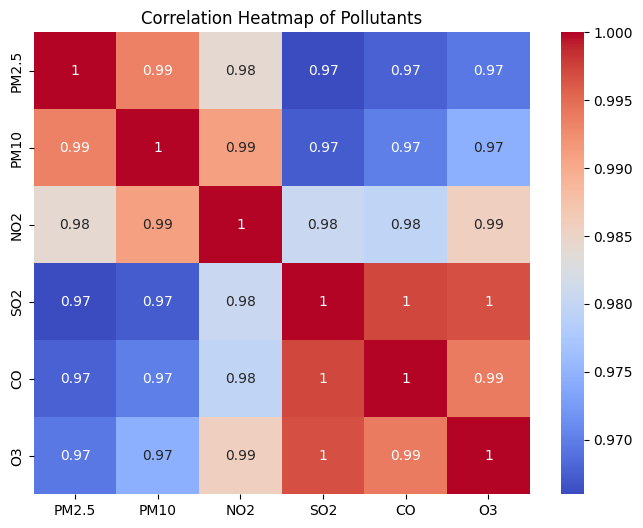

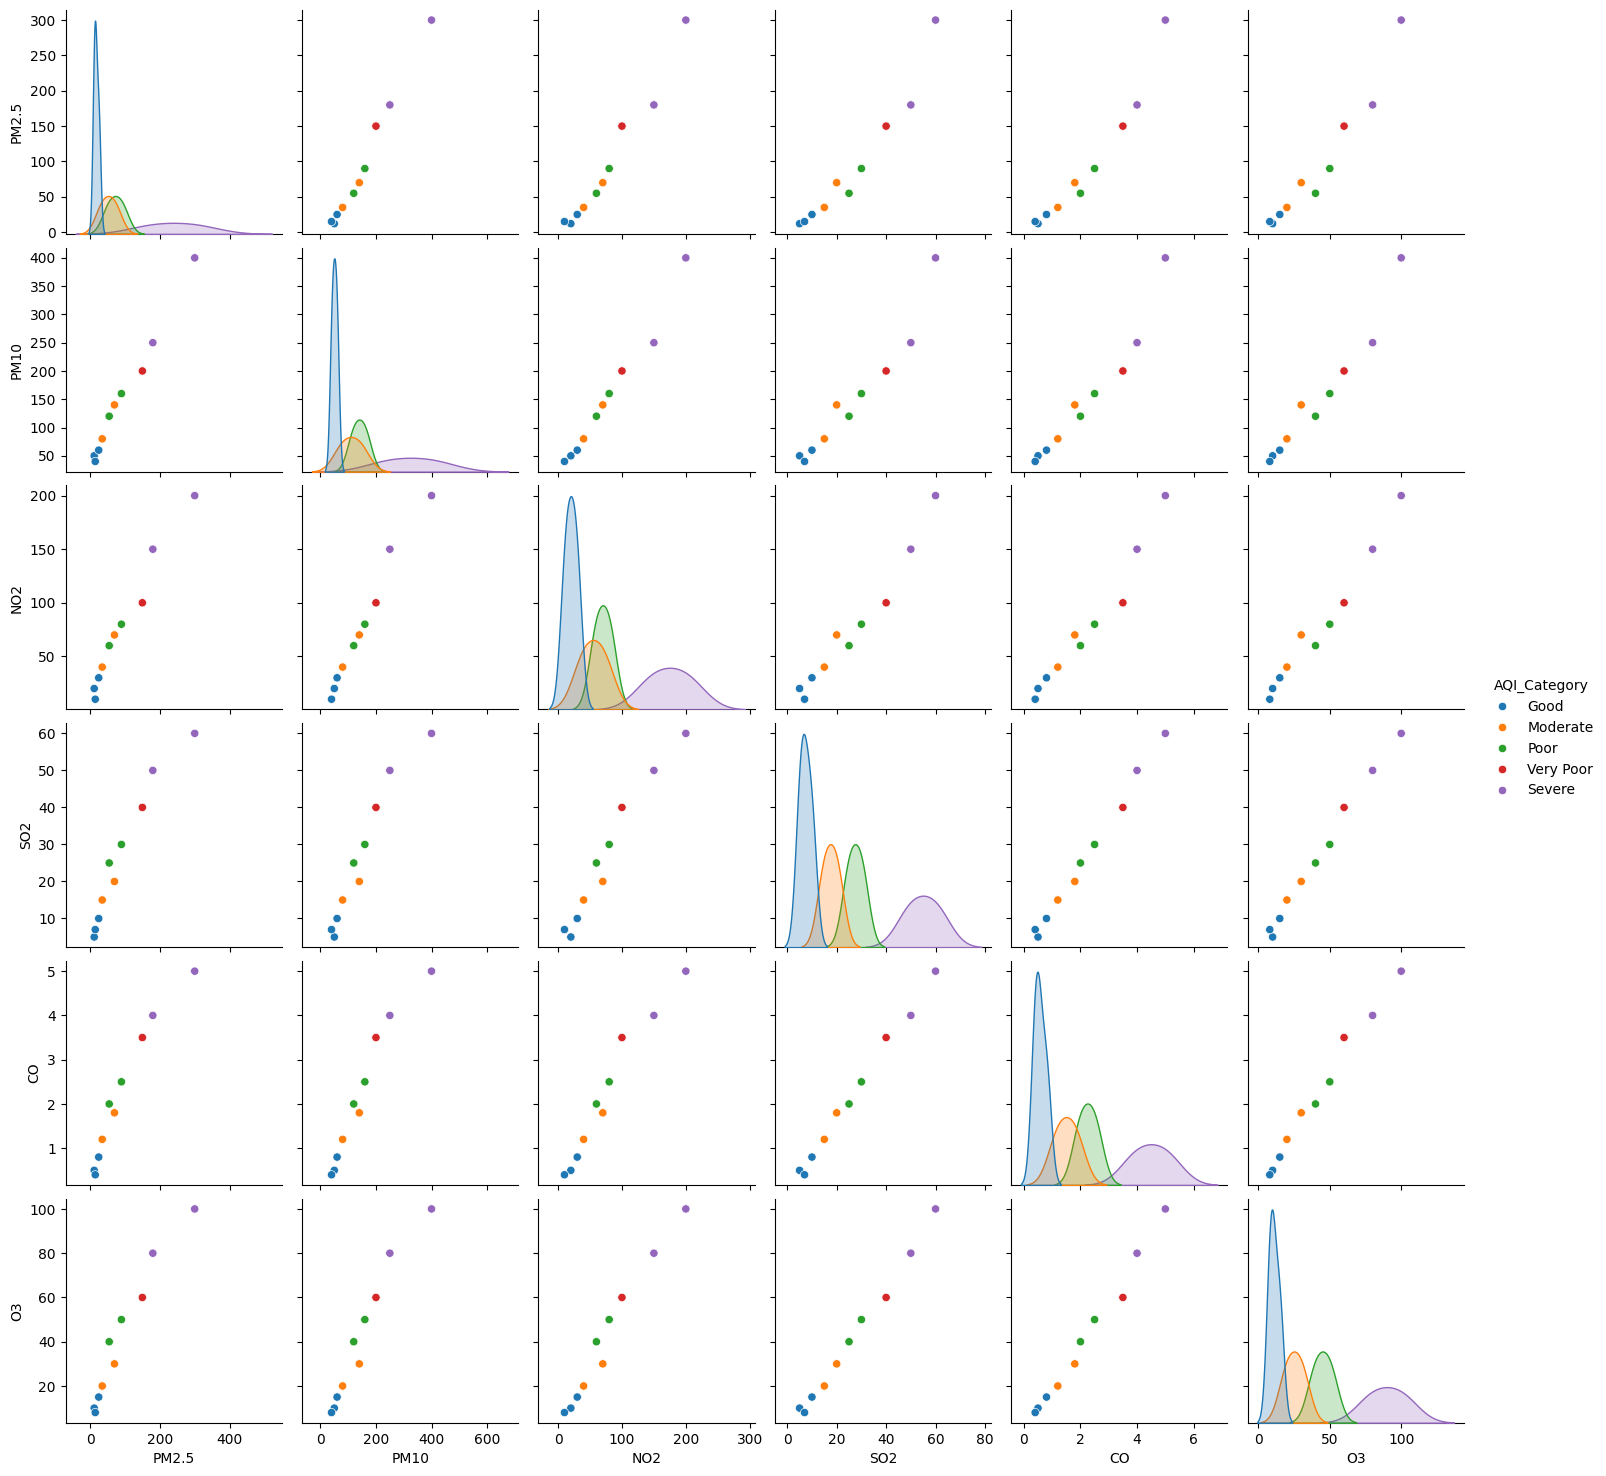

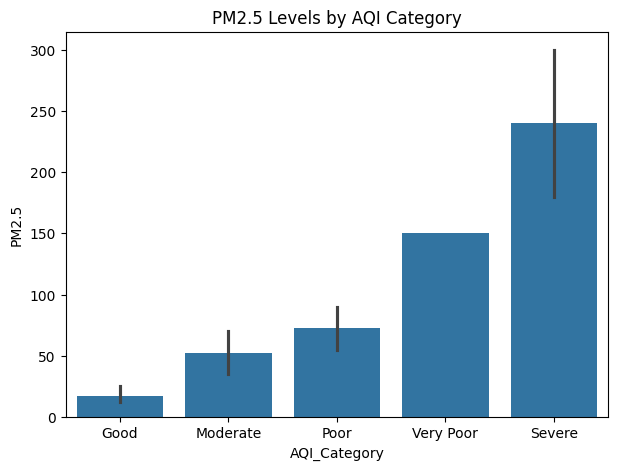

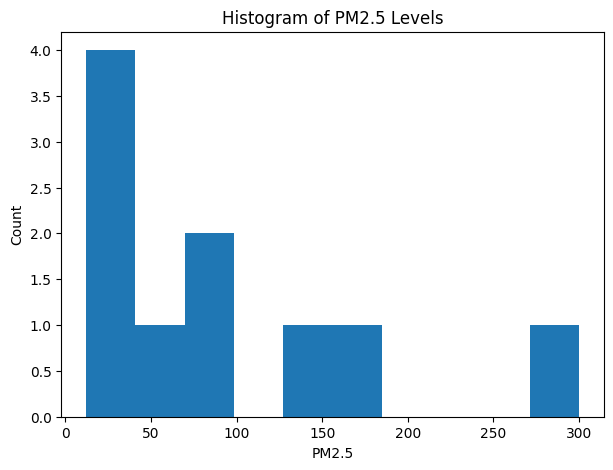

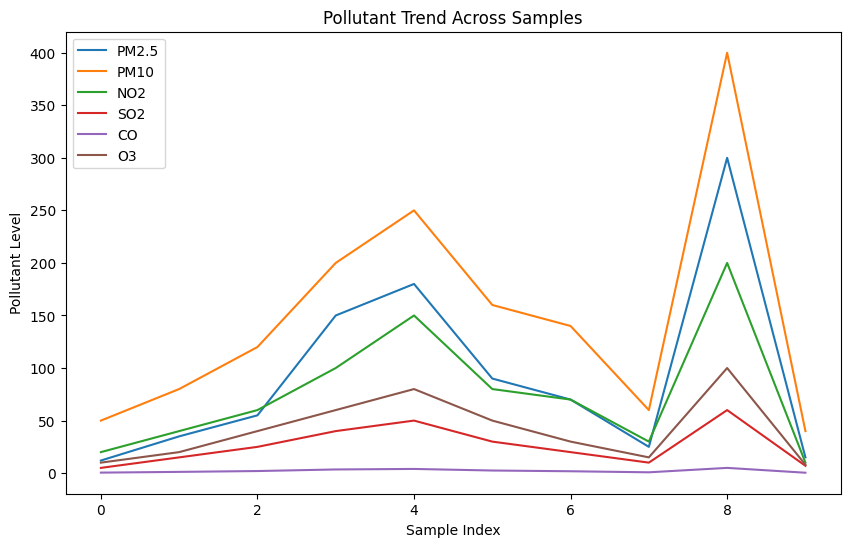

In [35]:
# -----------------------------------------------------------
# AIR POLLUTION DETECTION USING MACHINE LEARNING (FULL PROJECT)
# ERROR-FREE VERSION (NO STRATIFY ERROR)
# -----------------------------------------------------------

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------------
# STEP 1: CREATE DATASET (NO CSV NEEDED)
# ------------------------------------
df = pd.DataFrame({
    "PM2.5":  [12, 35, 55, 150, 180, 90, 70, 25, 300, 15],
    "PM10":   [50, 80, 120, 200, 250, 160, 140, 60, 400, 40],
    "NO2":    [20, 40, 60, 100, 150, 80, 70, 30, 200, 10],
    "SO2":    [5, 15, 25, 40, 50, 30, 20, 10, 60, 7],
    "CO":     [0.5, 1.2, 2.0, 3.5, 4.0, 2.5, 1.8, 0.8, 5.0, 0.4],
    "O3":     [10, 20, 40, 60, 80, 50, 30, 15, 100, 8],
    "AQI_Category": [
        "Good", "Moderate", "Poor", "Very Poor", "Severe",
        "Poor", "Moderate", "Good", "Severe", "Good"
    ]
})

print("Dataset created successfully!")
print(df)

# -------------------------
# STEP 2: FEATURES & TARGET
# -------------------------
X = df[["PM2.5", "PM10", "NO2", "SO2", "CO", "O3"]]
y = df["AQI_Category"]

# -------------------------
# STEP 3: ENCODING TARGET LABELS
# -------------------------
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# -------------------------
# STEP 4: TRAIN-TEST SPLIT (NO STRATIFY)
# -------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.3, random_state=42
)

# -------------------------
# STEP 5: TRAIN MODEL
# -------------------------
model = RandomForestClassifier()
model.fit(X_train, y_train)

# -------------------------
# STEP 6: EVALUATION
# -------------------------
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("\nModel Accuracy:", accuracy)

# -------------------------
# STEP 7: PREDICT NEW INPUT
# -------------------------
new_data = [[100, 180, 90, 35, 2.0, 70]]  # Example input
pred_class = model.predict(new_data)
final_output = le.inverse_transform(pred_class)

print("\nPrediction for new air sample:", final_output[0])

# ---------------------------------
# STEP 8: GRAPHS & VISUALIZATIONS
# ---------------------------------

# 1. Heatmap
plt.figure(figsize=(8,6))
sns.heatmap(X.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap of Pollutants")
plt.show()

# 2. Pairplot
sns.pairplot(df, hue="AQI_Category")
plt.show()

# 3. PM2.5 vs AQI Category
plt.figure(figsize=(7,5))
sns.barplot(x="AQI_Category", y="PM2.5", data=df)
plt.title("PM2.5 Levels by AQI Category")
plt.show()

# 4. Histogram of PM2.5
plt.figure(figsize=(7,5))
plt.hist(df["PM2.5"], bins=10)
plt.title("Histogram of PM2.5 Levels")
plt.xlabel("PM2.5")
plt.ylabel("Count")
plt.show()

# 5. Line Plot of Pollutants
plt.figure(figsize=(10,6))
plt.plot(df["PM2.5"], label="PM2.5")
plt.plot(df["PM10"], label="PM10")
plt.plot(df["NO2"], label="NO2")
plt.plot(df["SO2"], label="SO2")
plt.plot(df["CO"], label="CO")
plt.plot(df["O3"], label="O3")
plt.legend()
plt.title("Pollutant Trend Across Samples")
plt.xlabel("Sample Index")
plt.ylabel("Pollutant Level")
plt.show()
